# Лабораторная работа №1. Настройка окружения и разведочный анализ данных.

## Цель работы

Подготовить структуру проекта и провести разведочный анализ данных. Результаты первой лабораторной работы будут использоваться в дальнейшем цикле работ.

# Выполнение работы

Для дальнейшей работы был выбран датасет :
    Car Price prediction

### 12 Разведочный анализ данных датасета Car prediction

#### 1. Импорт библиотек

In [154]:
import pandas as pd
import matplotlib as plt
import seaborn as sns
import numpy as np
import pickle

#### 2. Загрузка данных

In [155]:
df = pd.read_csv('/home/mainuser/mf_project/data/car data.csv')

print("Размер данных:", df.shape)  
print("Столбцы:", list(df.columns))  
print("\nПервые 10 строк:")

df.head(10)

Размер данных: (301, 9)
Столбцы: ['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Driven_kms', 'Fuel_Type', 'Selling_type', 'Transmission', 'Owner']

Первые 10 строк:


,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0
5,vitara brezza,2018,9.25,9.83,2071,Diesel,Dealer,Manual,0
6,ciaz,2015,6.75,8.12,18796,Petrol,Dealer,Manual,0
7,s cross,2015,6.50,8.61,33429,Diesel,Dealer,Manual,0
8,ciaz,2016,8.75,8.89,20273,Diesel,Dealer,Manual,0
9,ciaz,2015,7.45,8.92,42367,Diesel,Dealer,Manual,0


#### Основная информация о данных

Метод df.info(show_counts=True) 

Показывает главную информацию о таблице (DataFrame) и заставляет ее выдать точное количество заполненных ячеек.

Параметр (show_counts=True) управляет показом непустых (заполненных) значений.

In [156]:
df.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


Преобразование текстовых данных в специальный тип категорий

In [157]:
df['Car_Name'] = df['Car_Name'].astype('category')
df['Fuel_Type'] = df['Fuel_Type'].astype('category')
df['Selling_type'] = df['Selling_type'].astype('category')
df['Transmission'] = df['Transmission'].astype('category')

Преобразование числовых признаков в специальный тип - числа целые и с плавающей запятой

In [158]:
df['Owner'] = df['Owner'].astype('int8')

df['Year'] = df['Year'].astype('float32')
df['Selling_Price'] = df['Selling_Price'].astype('float32')
df['Present_Price'] = df['Present_Price'].astype('float32')
df['Driven_kms'] = df['Driven_kms'].astype('float32')

df.describe() 

Метод  для быстрого получения описательной статистики по числовым столбцам.

In [159]:
df.describe()

,Year,Selling_Price,Present_Price,Driven_kms,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627930,4.661296,7.628471,36947.207031,0.043189
std,2.891554,5.082811,8.642585,38886.882812,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.599998,500000.000000,3.000000


Преобразование категориальных признаков  в список

In [160]:
cat_features = df.select_dtypes(include=['category']).columns.to_list()
cat_features

['Car_Name', 'Fuel_Type', 'Selling_type', 'Transmission']

Преобразование числовых признаков в список 

In [161]:
num_features = df.select_dtypes(include=['number']).columns.to_list()
num_features

['Year', 'Selling_Price', 'Present_Price', 'Driven_kms', 'Owner']

#### 4. Проверка на пропуски и дубликаты

In [162]:
print("Пропущенные значения в каждом столбце:")
print(df.isnull().sum())  

duplicates = df.duplicated().sum()  
print(f"\nКоличество дубликатов: {duplicates}")

if duplicates > 0:
    df = df.drop_duplicates()  
    print(f"Удалили {duplicates} дубликатов")
else:
    print("Дубликатов нет")

Пропущенные значения в каждом столбце:
Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64

Количество дубликатов: 2
Удалили 2 дубликатов


Подсчет уникальных значений, содержащихся в каждом столбце таблицы.

In [163]:
for cat in cat_features:
    print(f'{cat} - numer of unique = {df[cat].nunique()}')

Car_Name - numer of unique = 98
Fuel_Type - numer of unique = 3
Selling_type - numer of unique = 2
Transmission - numer of unique = 2


In [164]:
for col in cat_features:
    print(f'Unique categories in {col}: {df[col].value_counts()}')

Unique categories in Car_Name: Car_Name
city             26
corolla altis    16
verna            14
brio             10
fortuner         10
                 ..
ignis             1
omni              1
land cruiser      1
s cross           1
vitara brezza     1
Name: count, Length: 98, dtype: int64
Unique categories in Fuel_Type: Fuel_Type
Petrol    239
Diesel     58
CNG         2
Name: count, dtype: int64
Unique categories in Selling_type: Selling_type
Dealer        193
Individual    106
Name: count, dtype: int64
Unique categories in Transmission: Transmission
Manual       260
Automatic     39
Name: count, dtype: int64



Вывод: датасет состоит из 301 строки и 9 столбцов, после удаления дубликатов получается 299 строк.
Пропущенных значений невыявлено. 

Целевой переменной является Selling_Price. 
Минимум 0.10, а максимум 35. Среднее значение равно 4.66, а медиана 3.60.

#### 5. Очистка данных и сохранение в новый файл

In [165]:
df = df.loc[df['Year'] > 0]
df = df.query('Selling_Price > 0')
df = df.query('Present_Price > 0')
df = df.query('Driven_kms >= 0')
df = df.query('Owner >= 0')

In [166]:
df.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
Index: 299 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   Car_Name       299 non-null    category
 1   Year           299 non-null    float32 
 2   Selling_Price  299 non-null    float32 
 3   Present_Price  299 non-null    float32 
 4   Driven_kms     299 non-null    float32 
 5   Fuel_Type      299 non-null    category
 6   Selling_type   299 non-null    category
 7   Transmission   299 non-null    category
 8   Owner          299 non-null    int8    
dtypes: category(4), float32(4), int8(1)
memory usage: 11.7 KB


In [167]:
df['Car_Age'] = 2026 - df['Year'] 

print("Была добавлена 1 новая переменная")
print("Размер DataFrame после очистки:", df.shape)

print("\nПервые 5 строк с новым признаком:")
df[['Car_Name', 'Year', 'Car_Age']].head()

Была добавлена 1 новая переменная
Размер DataFrame после очистки: (299, 10)

Первые 5 строк с новым признаком:


,Car_Name,Year,Car_Age
0,ritz,2014.0,12.0
1,sx4,2013.0,13.0
2,ciaz,2017.0,9.0
3,wagon r,2011.0,15.0
4,swift,2014.0,12.0


Вывод: Был установлен фильтр: на отрицательные и в некоторых случаях на нулевые значения. После очистки невалидных данных выявлено не было. Также была добавлена новая переменная "Срок службы автомобиля". Других фильтров установлено не было.

#### 5. Анализ признаков для модели

In [168]:
import plotly.graph_objects as go
import matplotlib.pyplot as plt

График распределения цен машины 

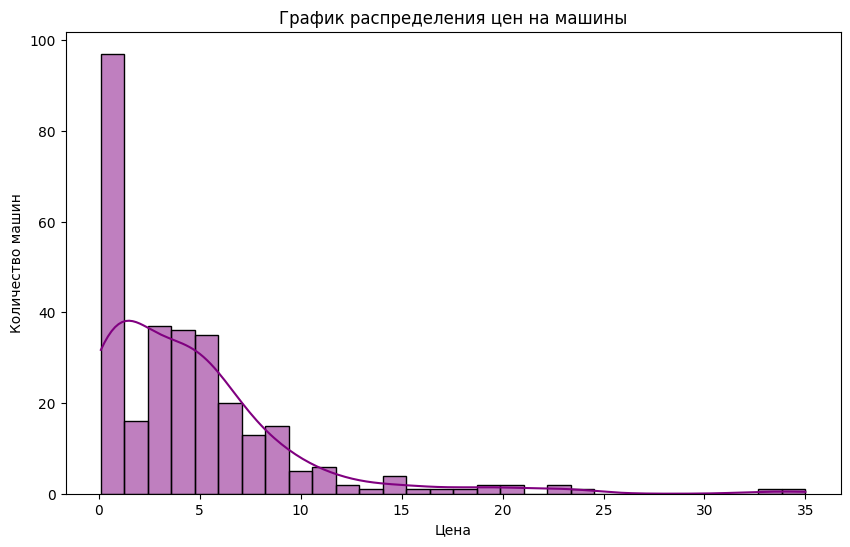

In [169]:
plt.figure(figsize=(10, 6))  
sns.histplot(df['Selling_Price'], kde=True, bins=30, color='purple')  
plt.title('График распределения цен на машины')  
plt.xlabel('Цена')  
plt.ylabel('Количество машин')  
plt.savefig('цены_машин.png') 
plt.show()  

Вывод: Большинство машин имеет стоимость ниже или равную 10 lakhs, помимо этого присутствуют и дорогие варианты машин.

График цена и год выпуска

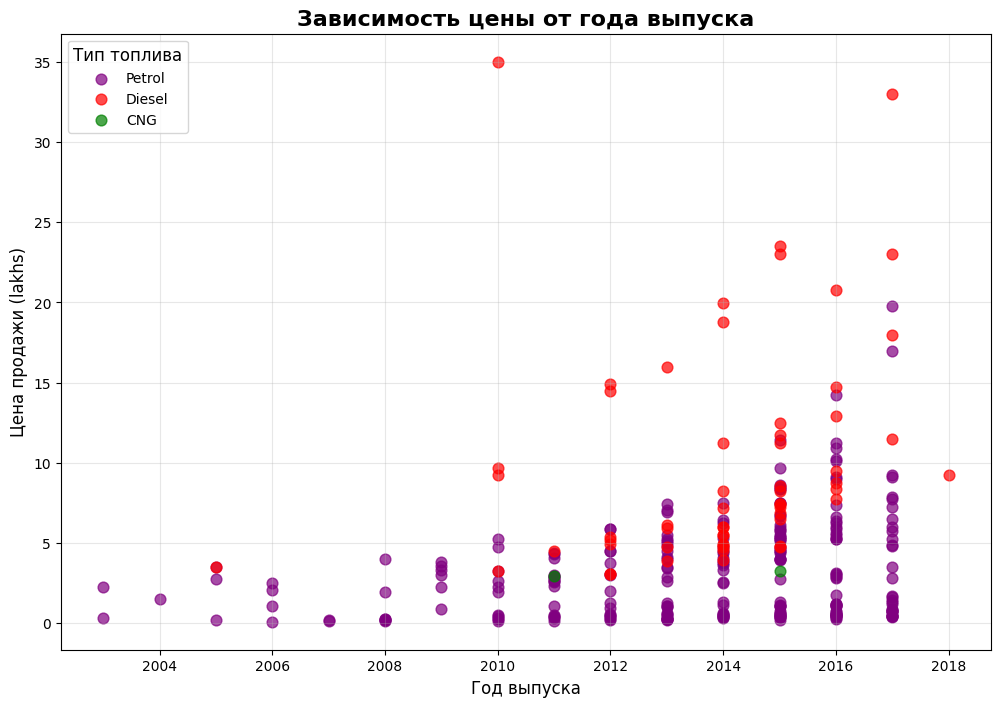

In [170]:
colors = {'Petrol': 'purple', 'Diesel': 'red', 'CNG': 'green'}

plt.figure(figsize=(12, 8))

for fuel_type in df['Fuel_Type'].unique():
    subset = df[df['Fuel_Type'] == fuel_type]
    plt.scatter(subset['Year'], subset['Selling_Price'],
                label=fuel_type, alpha=0.7, s=60,
                color=colors[fuel_type])

plt.title('Зависимость цены от года выпуска', fontsize=16, fontweight='bold')
plt.xlabel('Год выпуска', fontsize=12)
plt.ylabel('Цена продажи (lakhs)', fontsize=12)
plt.legend(title='Тип топлива', title_fontsize=12)
plt.grid(True, alpha=0.3)

plt.savefig('цена_и_год.png')
plt.show()

Вывод: Исходя из графика можно сделать вывод, что машины имеющие дизельный двигатель внутреннего сгорания стоят дороже, нежели машины на природном газе и машины на бензине. Также по графику видно, что чем новее машина, тем она дороже"

График корреляционная матрица

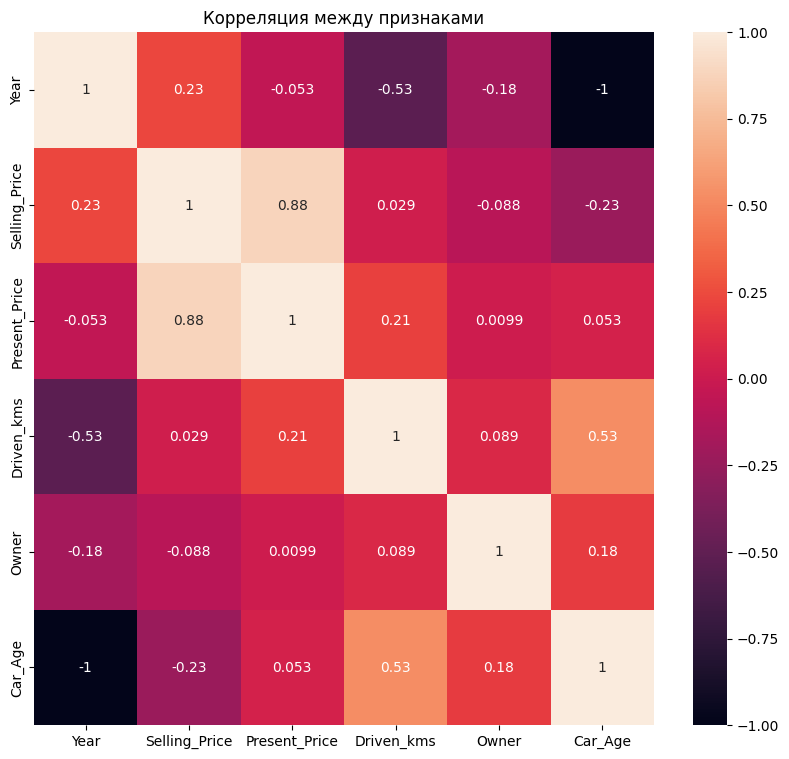

In [171]:
feature_correlation = df[num_features].corr()

plt.figure(figsize=(10, 9))  

sns.heatmap(numeric_df.corr(), annot=True)       
plt.title('Корреляция между признаками')  
plt.savefig('корреляционная_матрица.png')  
plt.show()  

Вывод: На корреляционной матрице видна сильная положительная связь между ценой продажи (Selling_Price) и текущей ценой (Present_Price) — коэффициент корреляции 0.88. Это означает, что цена продажи автомобиля в значительной степени определяется его первоначальной стоимостью. Также наблюдается заметная положительная корреляция между ценой продажи и годом выпуска (Year) — 0.24, что подтверждает, что более новые автомобили стоят дороже. Корреляция с пробегом (Driven_kms) и количеством владельцев (Owner) очень слабая, что говорит о их меньшем влиянии на цену в данном датасете.

График цен по типам топлива

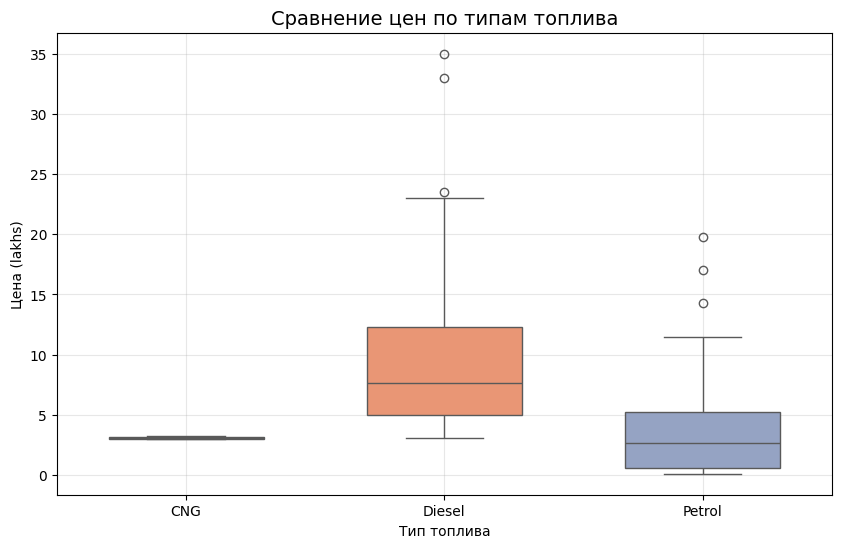

In [172]:
plt.figure(figsize=(10, 6))

sns.boxplot(x='Fuel_Type', y='Selling_Price', data=df, 
            hue='Fuel_Type', 
            legend=False,     
            width=0.6,
            palette='Set2')

plt.title('Сравнение цен по типам топлива', fontsize=14)
plt.xlabel('Тип топлива')
plt.ylabel('Цена (lakhs)')
plt.grid(True, alpha=0.3)

plt.savefig('цена_по_типам_топлива.png')
plt.show()

Вывод: видно, что медианная цена автомобилей с дизельным двигателем выше, чем у автомобилей на бензине. Это может быть связано с тем, что дизельные автомобили чаще представлены более дорогими моделями (внедорожники, кроссоверы). Также на графике присутствует несколько выбросов для дизельных автомобилей, что указывает на наличие очень дорогих машин в этой категории. Автомобили на газе (CNG) представлены всего двумя экземплярами, и их цена находится в низком диапазоне.

График цена от пробега

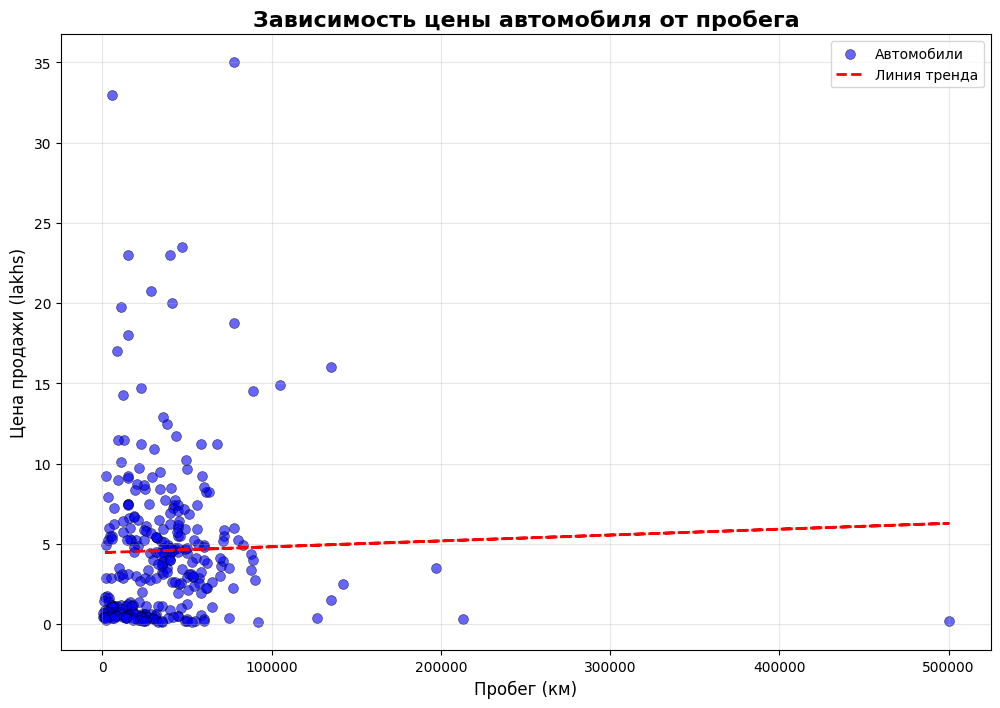

Коэффициент корреляции: 0.029


In [173]:
plt.figure(figsize=(12, 8))

plt.scatter(df['Driven_kms'], df['Selling_Price'],
            alpha=0.6,
            s=50,
            color='blue',
            edgecolors='black',
            linewidth=0.5,
            label='Автомобили')

z = np.polyfit(df['Driven_kms'], df['Selling_Price'], 1)
p = np.poly1d(z)
plt.plot(df['Driven_kms'], p(df['Driven_kms']),
         color='red',
         linewidth=2,
         linestyle='--',
         label='Линия тренда')

plt.title('Зависимость цены автомобиля от пробега', fontsize=16, fontweight='bold')
plt.xlabel('Пробег (км)', fontsize=12)
plt.ylabel('Цена продажи (lakhs)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

plt.savefig('цена_от_пробега.png')
plt.show()


correlation = df['Selling_Price'].corr(df['Driven_kms'])
print(f"Коэффициент корреляции: {correlation:.3f}")


Вывод: На диаграмме рассеяния видна слабая отрицательная связь между пробегом и ценой продажи. Коэффициент корреляции составляет 0.029, что говорит об очень слабой линейной зависимости. 
Большой разброс точек (особенно в диапазоне до 100 000 км) говорит о том, что пробег — не единственный и не главный фактор, определяющий цену. Тем не менее, автомобили с очень большим пробегом (более 150 000 км) имеют более низкую цену.

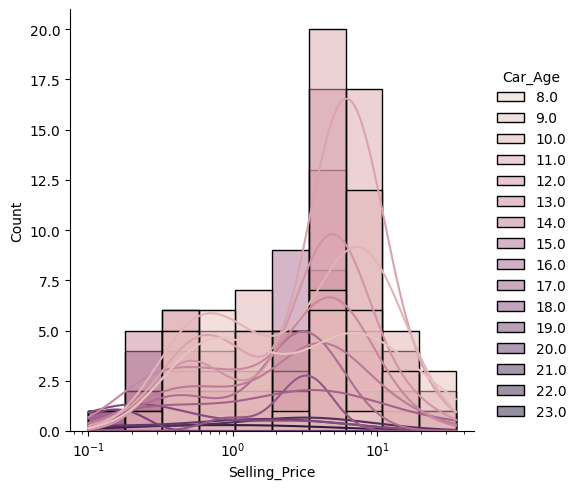

In [174]:
sns.displot(df, x='Selling_Price', bins=10, hue='Car_Age', kde=True, log_scale=True, color='red')

Вывод: Графики подтверждают ранее сделанные наблюдения. С увеличением возраста автомобиля (Car_Age) наблюдается  снижение цены продажи (Selling_Price_mean).

In [175]:
def flat_index(df_stats): 
    df_stats.columns = df_stats.columns.get_level_values(0) + '_' +  df_stats.columns.get_level_values(1) 
    df_stats.columns = df_stats.columns.to_flat_index() 
    df_stats.reset_index(inplace=True) 
    return df_stats

In [176]:
aggregated_df = df[num_features+['Car_Age']].groupby(by='Car_Age').agg(['mean', 'std'])
aggregated_df = flat_index(aggregated_df)
aggregated_df 

,Car_Age,Year_mean,Year_std,Selling_Price_mean,Selling_Price_std,Present_Price_mean,Present_Price_std,Driven_kms_mean,Driven_kms_std,Owner_mean,Owner_std
0,8.0,2018.0,NaN,9.250000,NaN,9.830000,NaN,2071.000000,NaN,0.000000,NaN
1,9.0,2017.0,0.0,6.209143,7.610526,7.037143,8.418047,10419.799805,9028.881423,0.000000,0.000000
2,10.0,2016.0,0.0,5.161428,4.740603,6.464286,5.862941,17885.041016,12469.857283,0.020408,0.142857
3,11.0,2015.0,0.0,5.642500,4.608432,7.808167,6.459565,31977.683594,14402.516558,0.016667,0.129099
4,12.0,2014.0,0.0,4.762105,4.324392,7.811658,7.783017,38080.316406,19310.390049,0.052632,0.226294
5,13.0,2013.0,0.0,3.540909,3.250883,6.821121,6.983980,41534.332031,23920.822559,0.030303,0.174078
6,14.0,2012.0,0.0,3.841304,3.942993,7.984782,8.517425,43798.218750,25502.573966,0.043478,0.208514
7,15.0,2011.0,0.0,2.375263,1.476977,5.148052,3.927316,40327.367188,23467.977897,0.052632,0.229416
8,16.0,2010.0,0.0,5.262666,8.767003,14.330667,23.112537,60014.066406,45429.155164,0.066667,0.258199
9,17.0,2009.0,0.0,2.816667,1.085664,10.601666,5.902682,67820.500000,16201.723411,0.000000,0.000000


<Axes: xlabel='Car_Age', ylabel='Selling_Price_mean'>

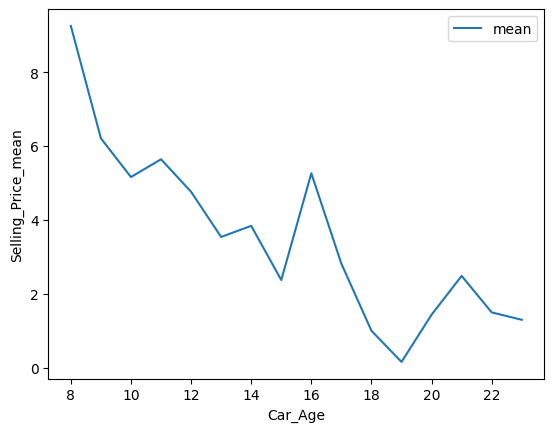

In [177]:
sns.lineplot(aggregated_df,x='Car_Age',y='Selling_Price_mean', label='mean')

<Axes: xlabel='Car_Age', ylabel='Owner_mean'>

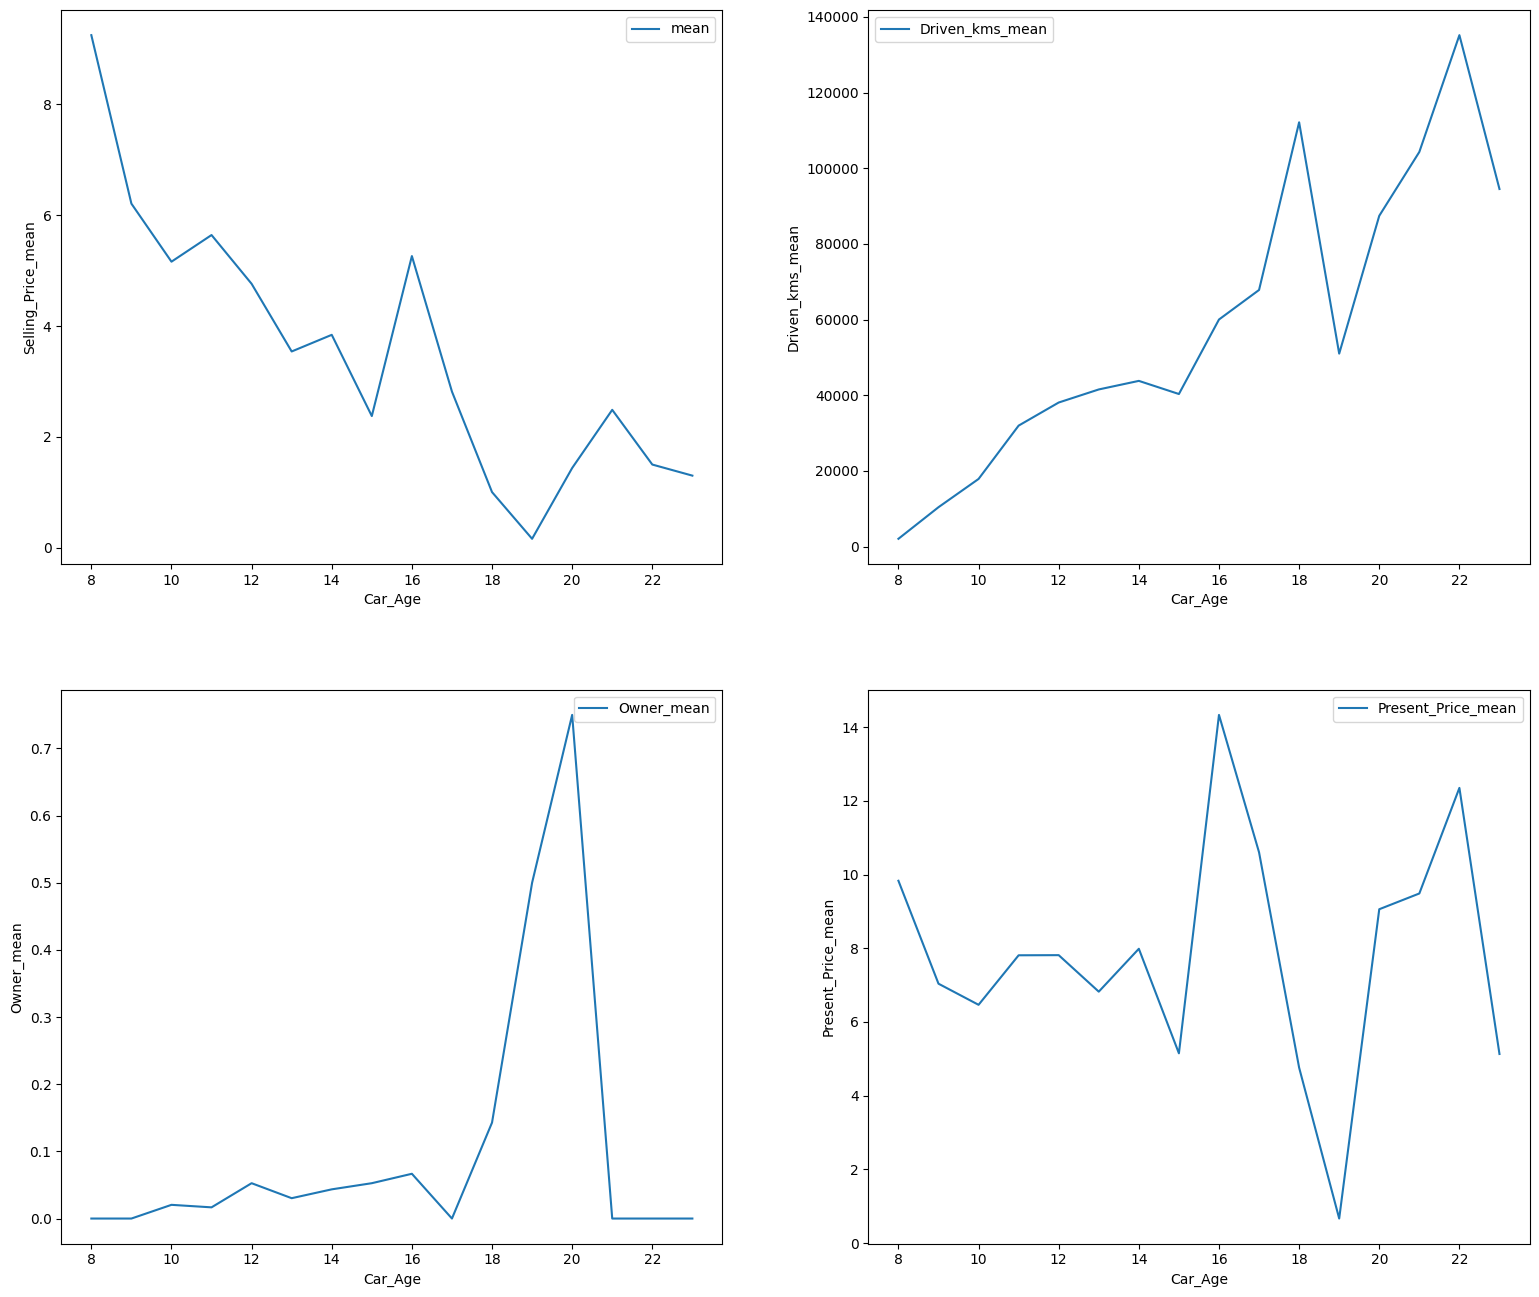

In [178]:
fig, axs = plt.subplots(2,2)
fig.tight_layout(pad=1)
fig.set_size_inches(16.5, 14, forward=True)

sns.lineplot(aggregated_df,x='Car_Age',y='Selling_Price_mean', label='mean', ax=axs[0,0])

sns.lineplot(aggregated_df,x='Car_Age',y='Driven_kms_mean', label='Driven_kms_mean',ax=axs[0,1])
sns.lineplot(aggregated_df,x='Car_Age',y='Present_Price_mean', label='Present_Price_mean',ax=axs[1,1])

sns.lineplot(aggregated_df,x='Car_Age',y='Owner_mean', label='Owner_mean',ax=axs[1,0])


Вывод: 
1. средняя цена продажи от возраста

Наблюдается ярко выраженная общая тенденция к снижению средней цены продажи с увеличением возраста автомобиля. Самые дорогие автомобили — самые новые (возраст 8 лет). Однако график не является монотонно убывающим: присутствуют заметные локальные всплески (например, в возрасте 11, 16 и 20 лет). Это может указывать на то, что на рынке периодически появляются более дорогие модели определённого возраста, что приводит к увеличению средней цены в этой группе. 

2. средний пробег от возраста

График демонстрирует чёткую положительную корреляцию: чем старше автомобиль, тем больше его средний пробег. 

3. среднее количество владельцев от возраста

Зависимость имеет ярко выраженный нелинейный характер. Для автомобилей возрастом от 8 до 18 лет среднее количество владельцев остаётся стабильно низким (близким к 0). Однако в возрасте 19–20 лет наблюдается резкий пик (до 0.75), после чего показатель снова падает почти до нуля. Это может говорить о том, что в датасете присутствует специфическая группа автомобилей именно этого возраста, которые часто перепродавались. Для более старых машин (21–23 года) этот показатель снова низкий, что может быть связано с небольшим количеством таких экземпляров в выборке.

4. средняя первоначальная цена от возраста

Этот график не показывает чёткой линейной зависимости. Средняя первоначальная цена сильно колеблется в зависимости от возраста. Наблюдаются значительные пики (например, в возрасте 16 и 22 лет) и глубокие падения (в возрасте 19 лет). Это означает, что среди автомобилей разного возраста встречаются как очень дорогие, так и очень дешёвые модели, и возраст не является определяющим фактором для их первоначальной стоимости. Вероятно, на этот показатель больше влияет конкретная марка и класс автомобиля, а не его возраст.

In [179]:
from bokeh.plotting import figure, show
from bokeh.models import ColumnDataSource,  HoverTool, Legend
from bokeh.io import output_notebook 
output_notebook()

Loading BokehJS ...

In [180]:
source = ColumnDataSource(data=df.sample(frac=0.1))
p = figure(width=1000)
p.scatter(source=source, x='Car_Age', y='Selling_Price' )
hover = HoverTool(tooltips=[('Driven_kms', '@Driven_kms'),
                              ('Owner', '@Owner'),
                              ('Selling_Price', '@Selling_Price')])

p.add_tools(hover)
show(p)

In [182]:
df.to_pickle('../data/clean_data.pkl')

print("DataFrame успешно сохранен в файл clean_car_data.pkl")

DataFrame успешно сохранен в файл clean_car_data.pkl


In [183]:
# Считать можно так:
df = pd.read_pickle('../data/clean_data.pkl')
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 299 entries, 0 to 300
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   Car_Name       299 non-null    category
 1   Year           299 non-null    float32 
 2   Selling_Price  299 non-null    float32 
 3   Present_Price  299 non-null    float32 
 4   Driven_kms     299 non-null    float32 
 5   Fuel_Type      299 non-null    category
 6   Selling_type   299 non-null    category
 7   Transmission   299 non-null    category
 8   Owner          299 non-null    int8    
 9   Car_Age        299 non-null    float32 
dtypes: category(4), float32(5), int8(1)
memory usage: 10.5 KB


## Итоговые выводы:



Целевая переменная Selling_Price имеет асимметричное распределение. Большинство автомобилей имеют цену до 10 lakhs, но присутствуют и дорогие экземпляры.

Ключевые факторы, влияющие на цену:

Наибольшее влияние: Present_Price (текущая цена) имеет самую сильную положительную корреляцию с ценой продажи (0.88).

Значительное влияние: Year (год выпуска) также сильно влияет на цену. Чем новее автомобиль, тем он дороже.

Слабое влияние: Driven_kms (пробег) и Owner (количество владельцев) показали слабую корреляцию с ценой, хотя и прослеживается тенденция к ее снижению с ростом этих показателей.

    

    

